Español:
# **La Crisis Política de la República del Perú: Visualización de Datos Presidenciales (1980 - Marzo 2026)**

**Autor:** Martín Alonso Milón Velarde

**Fecha de Publicación:** Marzo 12, 2026

El 21 de marzo de 2018, la renuncia del ex-mandatario peruano Pedro Pablo Kuczynski, mejor conocido como PPK, marcó el inicio de una crisis política a nivel nacional que continúa hasta el día de hoy. En los ultimos diez años, el Perú ha tenido nueve presidentes (sin incluir a Mercedes Aráoz). Desde que comenzó la crisis política, solo Francisco Sagasti ha podido terminar su mandato constitucional, aunque su mandato solo duró ocho meses y once dias. Del resto de mandatarios, cuatro fueron removidos por el congreso — Martin Vizcarra en 2020, Pedro Castillo en 2022, Dina Boluarte en 2025, y José Jerí en 2026 — y dos fueron forzados a renunciar — PPK en 2018 y Manuel Merino en 2020.

El objetivo de proyecto es describir cómo se ha accedido y cómo se abandonado el poder presidencial en el Perú desde la decada de los ochentas y generar visualizaciones que permitan explorar la naturaleza de la actual crisis política en el país. Para ello se utiliza un conjunto de datos en el que cada fila representa un **mandato presidencial específico**, identificado por el nombre del presidente y la fecha de inicio y fin de su gobierno. Además, el dataset registra atributos institucionales clave como el **periodo histórico**, el **modo de acceso al poder** (por ejemplo, elección o sucesión constitucional), el **modo de salida del cargo** (como finalización del mandato, renuncia o destitución congresal), el **origen político del presidente** y su **organización política**. A partir de las fechas de inicio y fin de cada mandato, también se calculan variables que miden la **duración del gobierno en días, meses y años**, lo que permite analizar comparativamente la estabilidad presidencial a lo largo del tiempo.


---


English:
# **The Political Crisis of the Republic of Peru: Visualization of Presidential Data (1980 - March 2026)**

**Author:** Martín Alonso Milón Velarde

**Publication Date:** March 12, 2026

On March 21, 2018, the resignation of former Peruvian president Pedro Pablo Kuczynski, better known as PPK, marked the beginning of a national political crisis that continues to this day. Over the past decade, Peru has had nine presidents (not including Mercedes Aráoz). Since the crisis began, only Francisco Sagasti has been able to complete a constitutional presidential term, although his administration lasted only eight months and eleven days. Among the remaining presidents, four were removed from office by Congress — Martín Vizcarra in 2020, Pedro Castillo in 2022, Dina Boluarte in 2025, and José Jerí in 2026 — while two were forced to resign — PPK in 2018 and Manuel Merino in 2020.

The objective of this project is to describe how presidential power has been both attained and relinquished in Peru since the 1980s, and to generate visualizations that allow for the exploration of the nature of the current political crisis in the country. For this purpose, the project uses a dataset in which each row represents a **specific presidential term**, identified by the name of the president and the start and end dates of the administration. The dataset also records key institutional attributes such as the **historical period**, the **mode of entry into office** (for example, election or constitutional succession), the **mode of exit from office** (such as completion of term, resignation, or congressional removal), the **president’s political origin**, and their **political organization**. Using the start and end dates of each term, additional variables are calculated to measure the **duration of each administration in days, months, and years**, allowing for a comparative analysis of presidential stability over time.

In [55]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# dataset
data = pd.read_csv("/content/presidential term durations.csv")

Español:
# Parte 1: Limpieza de Datos e Ingeniería de Variables

En esta sección se importan las librerías necesarias y se carga el conjunto de datos que contiene información sobre los mandatos presidenciales en el Perú. Posteriormente, los datos se limpian y se transforman para prepararlos para el análisis y la visualización.

1. Las fechas de inicio y fin de cada mandato presidencial se convierten al formato datetime, lo que permite realizar cálculos basados en el tiempo.

2. A partir de estas fechas, el script calcula la duración de cada mandato presidencial en días, meses y años.

3. Se genera una etiqueta que combina el nombre del presidente con el año en que comenzó su mandato, la cual se utilizará en los gráficos.

4. El conjunto de datos se ordena cronológicamente según la fecha de inicio de cada mandato.

Finalmente, se inspecciona la estructura del dataset para verificar que las variables se hayan creado correctamente.


---


English:
# Part 1: Data Cleaning and Feature Engineering

This section imports the required libraries and loads the dataset containing information about presidential terms in Peru. The data is then cleaned and transformed to prepare it for analysis and visualization.

1. The start and end dates of each presidential term are converted into datetime format to allow time-based calculations.

2. Using these dates, the script computes the duration of each presidential term in days, months, and years.

3. A label combining the president's name and the year their term began is generated for use in charts.

4. The dataset is sorted chronologically by the start date of each term.

Finally, the structure of the dataset is inspected to verify that the variables have been created correctly.

In [56]:
# dates
data['Term Start'] = pd.to_datetime(data['Term Start'])
data['Term End'] = pd.to_datetime(data['Term End'])

# remove presidents with no effective authority
data = data[data["Effective Authority"] != "No"]

# term duration
data['Term Duration'] = data ['Term End'] - data['Term Start']
data['Term Duration (days)'] = data['Term Duration'].dt.days
data['Term Duration (months)'] = data['Term Duration'].dt.days / 30.44
data['Term Duration (years)'] = data['Term Duration'].dt.days / 365.25

# president labels
data["President Label"] = (
    data["President"] + " (" +
    data["Term Start"].dt.year.astype(str) + ")"
)

# sort chronologically by start date
data = data.sort_values("Term Start")

# explore data structure
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 0 to 20
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype          
---  ------                  --------------  -----          
 0   Period                  19 non-null     object         
 1   President               19 non-null     object         
 2   Term Start              19 non-null     datetime64[ns] 
 3   Term End                19 non-null     datetime64[ns] 
 4   Mode of Entry           19 non-null     object         
 5   Basis for Entry         8 non-null      object         
 6   Mode of Exit            19 non-null     object         
 7   Department of Origin    19 non-null     object         
 8   Political Organization  17 non-null     object         
 9   Official Title          19 non-null     object         
 10  Effective Authority     0 non-null      object         
 11  First Vice President    11 non-null     object         
 12  Second Vice President   10 non-null     obj

Español:
# Parte 2: Subconjuntos de Periodos Históricos y Agregación de la Presidencia de Fujimori

En esta sección se preparan conjuntos de datos alternativos para analizar distintas fases de la historia política reciente del Perú. Primero, se crean subconjuntos del dataset original eliminando de manera secuencial determinados periodos históricos. Esto permite que el análisis se concentre en marcos temporales específicos, como el periodo democrático posterior al año 2000 o las crisis políticas más recientes. Se construyen tres datasets filtrados:

1. data2000 elimina el periodo 1980–2000: Era del Terrorismo y el Fujimorismo, permitiendo que el análisis comience después de la caída del régimen de Fujimori.

2. data2016 elimina el periodo 2000–2016: República Empresarial, aislando el periodo contemporáneo de inestabilidad política.

3. data2020 elimina el periodo 2016–2020: Primera Crisis Política, concentrándose exclusivamente en la fase más reciente de la crisis.

Además, el dataset se modifica para combinar los múltiples periodos presidenciales de Alberto Fujimori en una sola observación que represente todo su tiempo en el poder (1990–2000). Dado que Fujimori gobernó a través de varias fases institucionales —incluyendo el autogolpe de 1992 y la transición constitucional de 1993— su presidencia aparece en múltiples filas dentro del dataset original. Para ciertas visualizaciones, estos periodos se agregan en un solo mandato continuo sumando sus duraciones y creando una nueva fila consolidada.


---


English:
# Part 2: Subsetting Historical Periods and Aggregating Fujimori’s Presidency

This section prepares alternative datasets to analyze different phases of Peru’s recent political history. First, subsets of the original dataset are created by sequentially removing historical periods. This allows the analysis to focus on specific time frames, such as the post-2000 democratic period or the recent political crises. Three filtered datasets are constructed:

1. data2000 removes the period 1980–2000: Era of Terrorism and Fujimorismo, allowing analysis to begin after the fall of Fujimori’s regime.

2. data2016 removes the period 2000–2016: Business Republic, isolating the contemporary period of political instability.

3. data2020 removes the period 2016–2020: First Political Crisis, focusing exclusively on the most recent phase of the crisis.

Second, the dataset is modified to combine the multiple presidential periods of Alberto Fujimori into a single observation representing his entire time in power (1990–2000). Since Fujimori governed through several institutional phases—including the 1992 self-coup and the 1993 constitutional transition—his presidency appears in multiple rows in the original dataset. For certain visualizations, these periods are aggregated into a single continuous tenure by summing their durations and creating a new consolidated row.

In [57]:
# remove period = 1980–2000: Era of Terrorism and Fujimorismo
data2000 = data[data["Period"] != "1980–2000: Era of Terrorism and Fujimorismo"]
data2000 = data2000.sort_values("Term Start")

# remove period = 2000–2016: Business Republic
data2016 = data2000[data2000["Period"] != "2000–2016: Business Republic"]
data2016 = data2016.sort_values("Term Start")

# remove period = 2016–2020: First Political Crisis
data2020 = data2016[data2016["Period"] != "2016–2020: First Political Crisis"]
data2020 = data2020.sort_values("Term Start")

# combine Fujimori periods
fujimori_total = data[data["President"] == "Alberto Fujimori"]["Term Duration (years)"].sum()

# eliminate Fujimori rows
no_fujimori = data[data["President"] != "Alberto Fujimori"]

# create new Fujimori row
fujimori_row = pd.DataFrame({
    "President": ["Alberto Fujimori"],
    "President Label": ["Alberto Fujimori (1990)"],
    "Term Duration (years)": [fujimori_total],
    "Period": ["1980–2000: Era of Terrorism and Fujimorismo"],
    "Term Start": [pd.Timestamp("1990-07-28")],
    "Term End": [pd.Timestamp("2000-11-21")],
    "Mode of Entry": ["Election"],
    "Mode of Exit": ["Resignation"],
})

# add new Fujimori row
fujimori_combined = pd.concat([no_fujimori, fujimori_row], ignore_index=True)

# sort data
fujimori_combined = fujimori_combined.sort_values(by="Term Start", ascending=True)

Español:

# Parte 3: Funciones de Visualización

En esta sección se definen dos funciones que permiten visualizar distintos aspectos de la duración y la secuencia temporal de los mandatos presidenciales en el Perú. Estas funciones utilizan el dataset previamente limpiado y permiten generar gráficos que exploran diferentes dimensiones del ejercicio del poder presidencial. Cada función recibe dos parámetros:

1. **data**: el dataset que contiene la información de los mandatos presidenciales.

2. **color_attribute**: el atributo que se utilizará para asignar los colores de las barras en el gráfico. Este atributo puede corresponder a distintas variables del dataset, como por ejemplo:

- Period
- Mode of Entry
- Mode of Exit

Las funciones están diseñadas para facilitar el análisis exploratorio de los datos y permiten observar patrones relacionados con la duración de los mandatos presidenciales, las transiciones institucionales y los distintos periodos históricos de la política peruana.

1. **plot_timeline()**

Esta función genera una visualización tipo línea de tiempo de los mandatos presidenciales. Cada presidente se representa mediante una barra horizontal que se extiende desde la fecha de inicio hasta la fecha de finalización de su mandato. El eje temporal se ajusta dinámicamente según las fechas presentes en el dataset.

2. **plot_horizontal_duration()**

Esta función genera un gráfico de barras horizontales que muestra la duración de los mandatos presidenciales. El eje horizontal representa los años de duración del mandato, mientras que el eje vertical muestra a los presidentes en orden cronológico.

En los gráficos producidos por las dos funciones, los colores de las barras se asignan automáticamente según el atributo seleccionado, y se incluye una leyenda para facilitar la interpretación del gráfico.



---



English:

# Part 3: Visualization Functions

This section defines two functions used to visualize different aspects of presidential tenure in Peru. These functions operate on the cleaned dataset created in the previous sections and allow the generation of charts that explore different dimensions of presidential power. Each function receives two parameters:

1. **data**: the dataset containing presidential term information.

2. **color_attribute**: the attribute used to determine the color mapping of the bars in the visualization. This attribute can represent different variables in the dataset, such as:

- Period
- Mode of Entry
- Mode of Exit

The functions are designed to support exploratory data analysis and help identify patterns related to presidential tenure, institutional transitions, and historical phases of Peruvian politics.

1. **plot_timeline()**

This function generates a timeline visualization of presidential terms. Each president is represented by a horizontal bar spanning from the start date to the end date of their time in office. The time axis adjusts dynamically based on the dates present in the dataset.

2. **plot_horizontal_duration()**

This function produces a horizontal bar chart displaying the duration of presidential terms. The horizontal axis represents the number of years in office, while the vertical axis lists presidents in chronological order.

In all visualizations produced by the two functions, bar colors are automatically assigned according to the selected attribute, and a legend is included to facilitate interpretation of the chart.

In [58]:
def plot_timeline(data, color_attribute):

    # Color mapping by selected attribute
    methods = data[color_attribute].unique()
    cmap = plt.get_cmap("tab10", len(methods))
    color_dict = {method: cmap(i) for i, method in enumerate(methods)}
    bar_colors = data[color_attribute].map(color_dict)

    # Dynamic x-axis limits
    min_date = data["Term Start"].min()
    max_date = data["Term End"].max()

    # Optional padding so bars don't touch the borders
    min_date = min_date - pd.DateOffset(months=6)
    max_date = max_date + pd.DateOffset(months=6)

    # Plot size
    plt.figure(figsize=(15, 6))

    # Horizontal bars showing duration
    plt.barh(
        data["President"],
        data["Term End"] - data["Term Start"],
        left=data["Term Start"],
        color=bar_colors
    )

    plt.xlabel("Year")
    plt.ylabel("President")
    plt.title("Timeline of Peruvian Presidents")

    # Format x-axis
    plt.xlim(min_date, max_date)
    plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.xticks(rotation=90)
    plt.grid(axis="x")
    plt.grid(axis="y")
    plt.gca().invert_yaxis()
    plt.gca().spines[['top', 'right']].set_visible(False)

    # Add legend
    for method in methods:
        plt.bar(0, 0, color=color_dict[method], label=method)

    plt.legend(
        title=color_attribute,
        loc="upper right",
        bbox_to_anchor=(0.9, -0.15)
    )

    # Add source note
    plt.figtext(
        0.001,
        0.005,
        "Source: Martin Milon Velarde (March 13, 2026)",
        ha="left",
        fontsize=9,
        style="italic"
    )

    plt.tight_layout(rect=[0,0.05,1,1])
    plt.show()

In [59]:
def plot_horizontal_duration(data, color_attribute):

    # Generate automatic color mapping
    periods = data[color_attribute].unique()
    cmap = plt.get_cmap("tab10", len(periods))
    color_dict = {period: cmap(i) for i, period in enumerate(periods)}
    bar_colors = data[color_attribute].map(color_dict)

    # Create bar chart
    plt.figure(figsize=(10,5))

    plt.barh(
        data["President Label"],
        data["Term Duration (years)"],
        color=bar_colors
    )

    # Invert axis so earliest appears on top
    plt.gca().invert_yaxis()

    plt.xlabel("Term Duration (Years)")
    plt.ylabel("Presidential Term")
    plt.title("Peruvian Presidential Term Durations (1980-Present)")

    # dynamic x-axis
    max_duration = data["Term Duration (years)"].max()
    plt.xlim(0, max_duration + 1)
    plt.xticks(range(0, int(max_duration) + 2))
    plt.grid(axis="x", linestyle="--", alpha=0.7)

    # Create legend
    for period in periods:
        plt.bar(0,0,color=color_dict[period],label=period)

    plt.legend(
        title=color_attribute,
        bbox_to_anchor=(0.5,-0.18),
        loc="upper center",
        ncol=2
    )

    # Add source note
    plt.figtext(
        0.001,
        0.005,
        "Source: Martin Milon Velarde (March 13, 2026)",
        ha="left",
        fontsize=9,
        style="italic"
    )

    plt.tight_layout(rect=[0,0.05,1,1])
    plt.show()

Español:

# Parte 4: Estrategia de Visualización para Analizar la Crisis Presidencial

Los siguientes gráficos tienen como objetivo examinar la evolución de la estabilidad presidencial en el Perú mediante dos enfoques complementarios: **la duración de los mandatos** y **la secuencia temporal del poder ejecutivo**.

Los **gráficos de duración de mandatos** permiten comparar cuánto tiempo permanecen los presidentes en el poder. Esto ayuda a identificar cambios en la estabilidad del sistema presidencial, particularmente al observar si los gobiernos logran completar sus mandatos o si terminan de forma anticipada.

Los **gráficos de línea de tiempo** permiten visualizar la sucesión cronológica de presidentes. Este tipo de visualización facilita detectar momentos de continuidad institucional o, por el contrario, periodos de rápida rotación presidencial asociados con crisis políticas.

Además, los gráficos clasifican los mandatos según tres dimensiones institucionales clave:

- **Periodo histórico**, para observar cómo cambia la estabilidad presidencial entre distintas etapas políticas.
- **Modo de acceso al poder**, para identificar si los presidentes llegan al cargo principalmente por elecciones o por mecanismos de sucesión constitucional.
- **Modo de salida del poder**, para examinar si los gobiernos terminan mediante la finalización del mandato o a través de renuncias, destituciones u otras interrupciones institucionales.

En conjunto, estas visualizaciones buscan revelar patrones de estabilidad e inestabilidad presidencial y proporcionar una base visual para interpretar la crisis política contemporánea en el Perú.



---

English:

# Part 4: Visualization Strategy for Analyzing the Presidential Crisis

The following charts are designed to examine the evolution of presidential stability in Peru through two complementary perspectives: **the duration of presidential terms** and **the chronological sequence of executive power**.

**Term duration charts** allow comparisons of how long presidents remain in office. This makes it possible to identify changes in the stability of the presidential system, particularly by observing whether governments complete their terms or end prematurely.

**Timeline charts** visualize the chronological succession of presidents. This type of visualization helps identify periods of institutional continuity as well as moments of rapid presidential turnover associated with political crises.

In addition, the charts classify presidential terms according to three key institutional dimensions:

- **Historical period**, to observe how presidential stability changes across political eras.
- **Mode of entry into office**, to identify whether presidents primarily come to power through elections or through constitutional succession.
- **Mode of exit from office**, to examine whether governments end through term completion or through resignations, removals, or other institutional interruptions.

Taken together, these visualizations aim to reveal patterns of presidential stability and instability and to provide a visual basis for interpreting Peru’s contemporary political crisis.

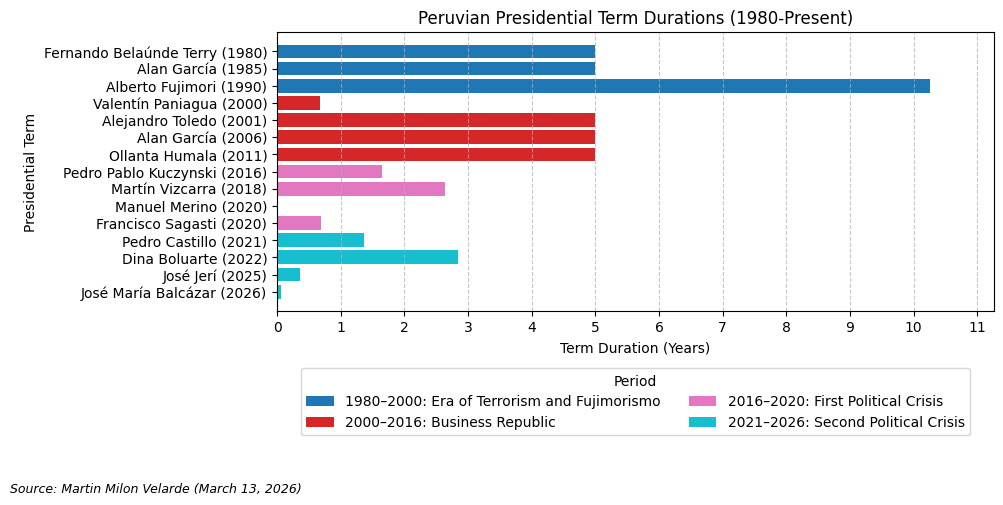

In [60]:
plot_horizontal_duration(fujimori_combined, "Period")

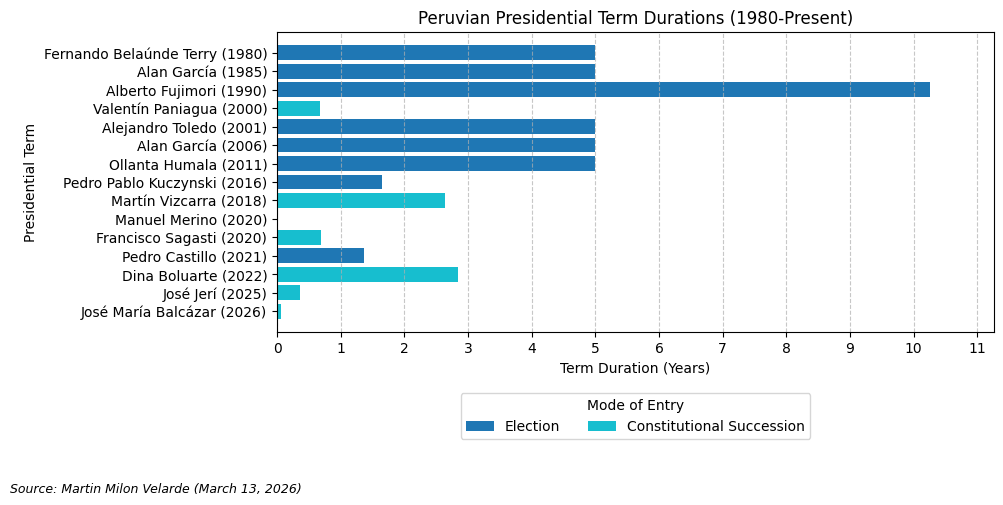

In [61]:
plot_horizontal_duration(fujimori_combined, "Mode of Entry")

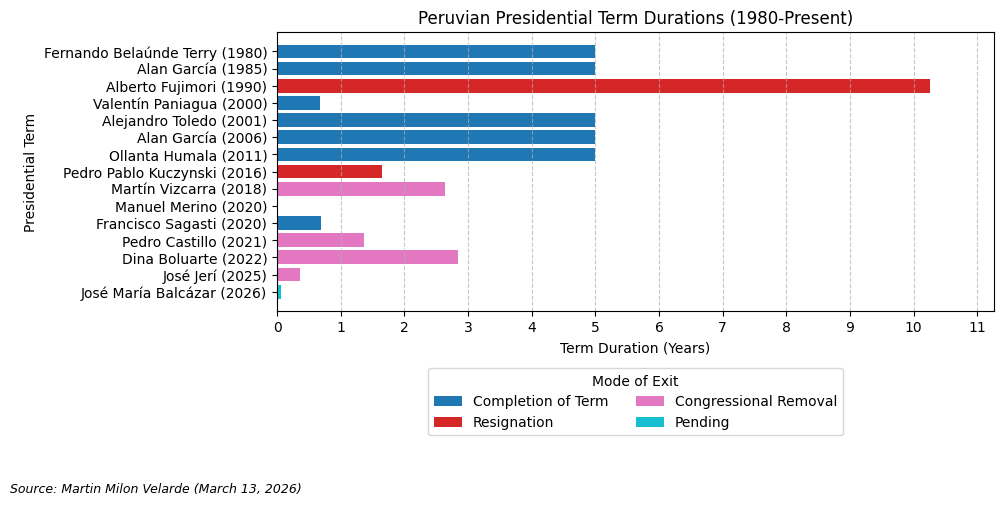

In [62]:
plot_horizontal_duration(fujimori_combined, "Mode of Exit")

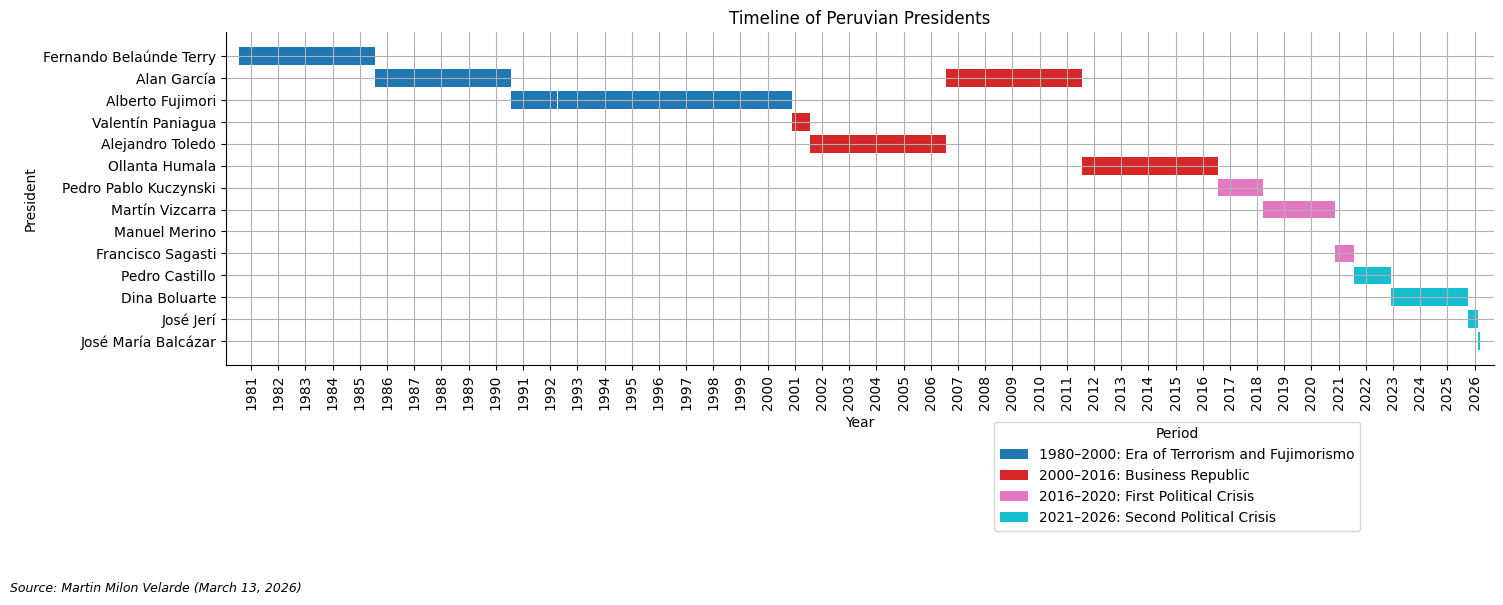

In [63]:
plot_timeline(data, "Period")

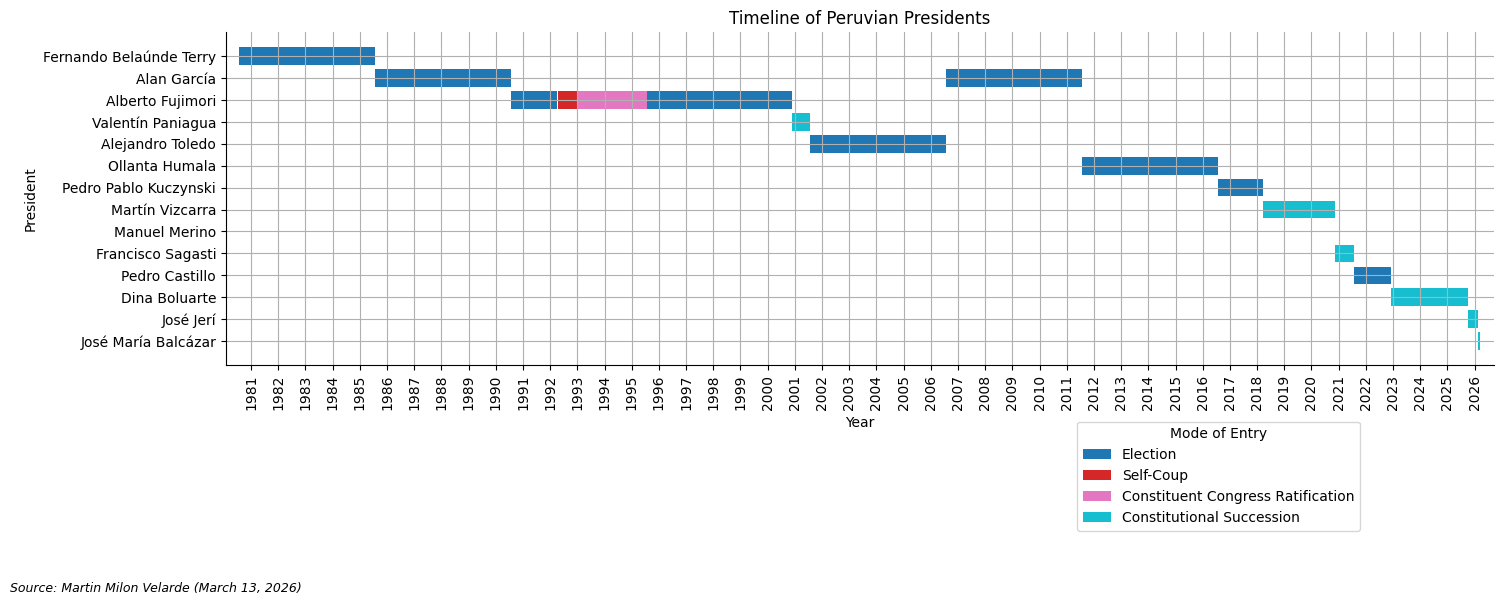

In [64]:
plot_timeline(data, "Mode of Entry")

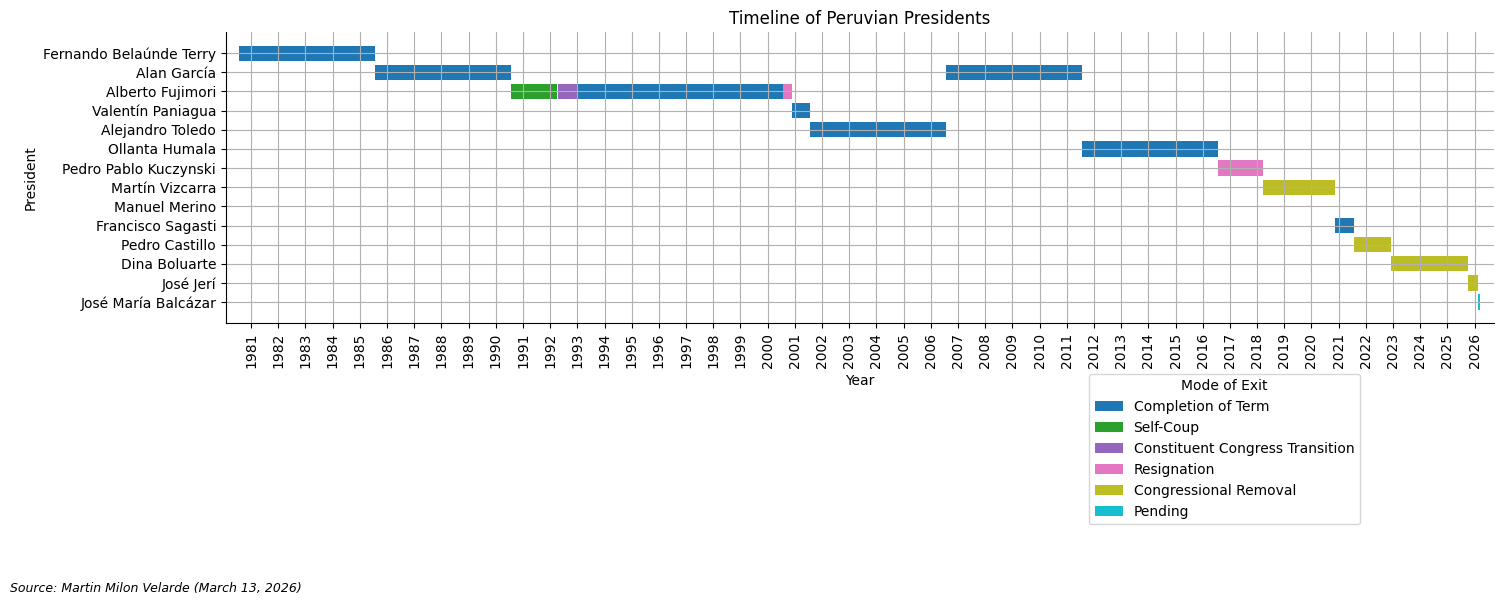

In [65]:
plot_timeline(data, "Mode of Exit")

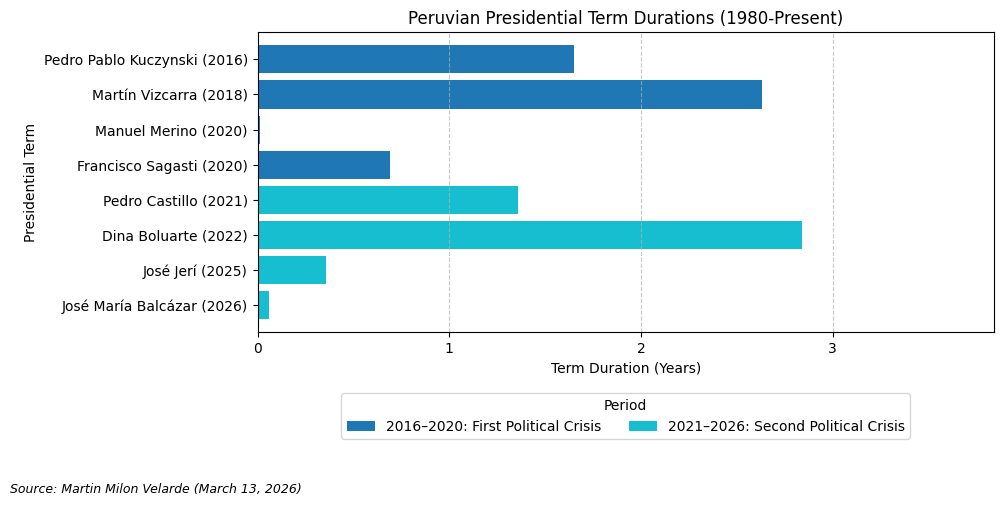

In [66]:
plot_horizontal_duration(data2016, "Period")

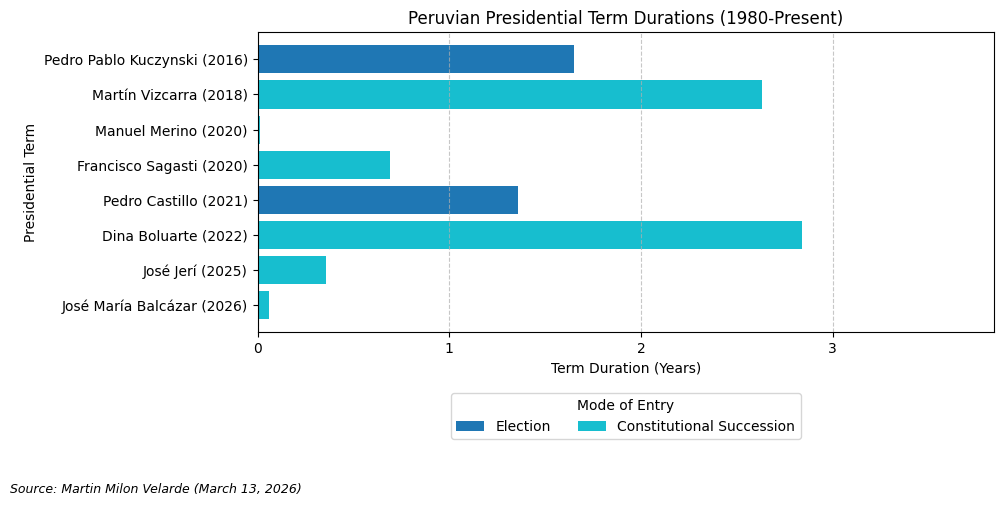

In [67]:
plot_horizontal_duration(data2016, "Mode of Entry")

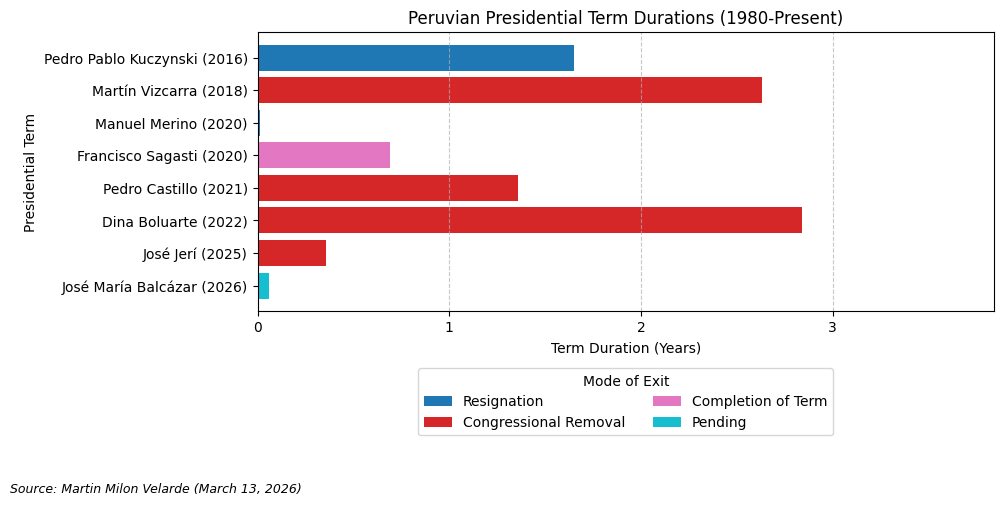

In [68]:
plot_horizontal_duration(data2016, "Mode of Exit")

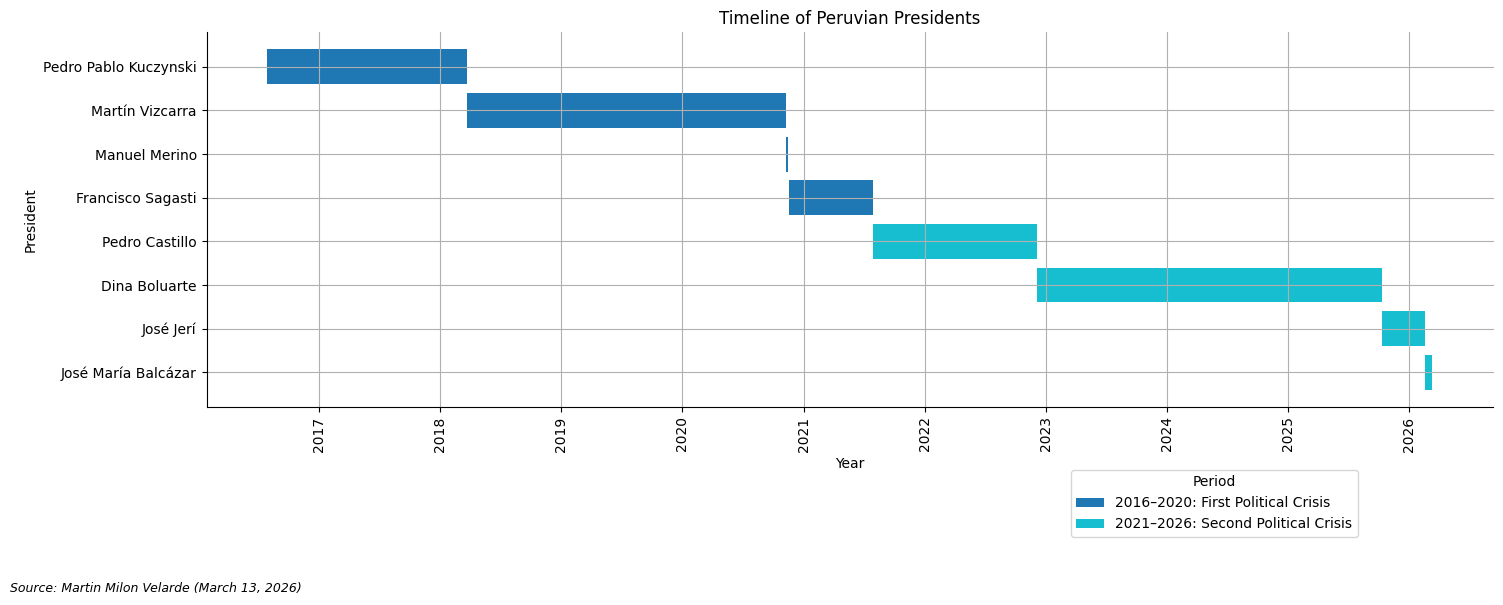

In [69]:
plot_timeline(data2016, "Period")

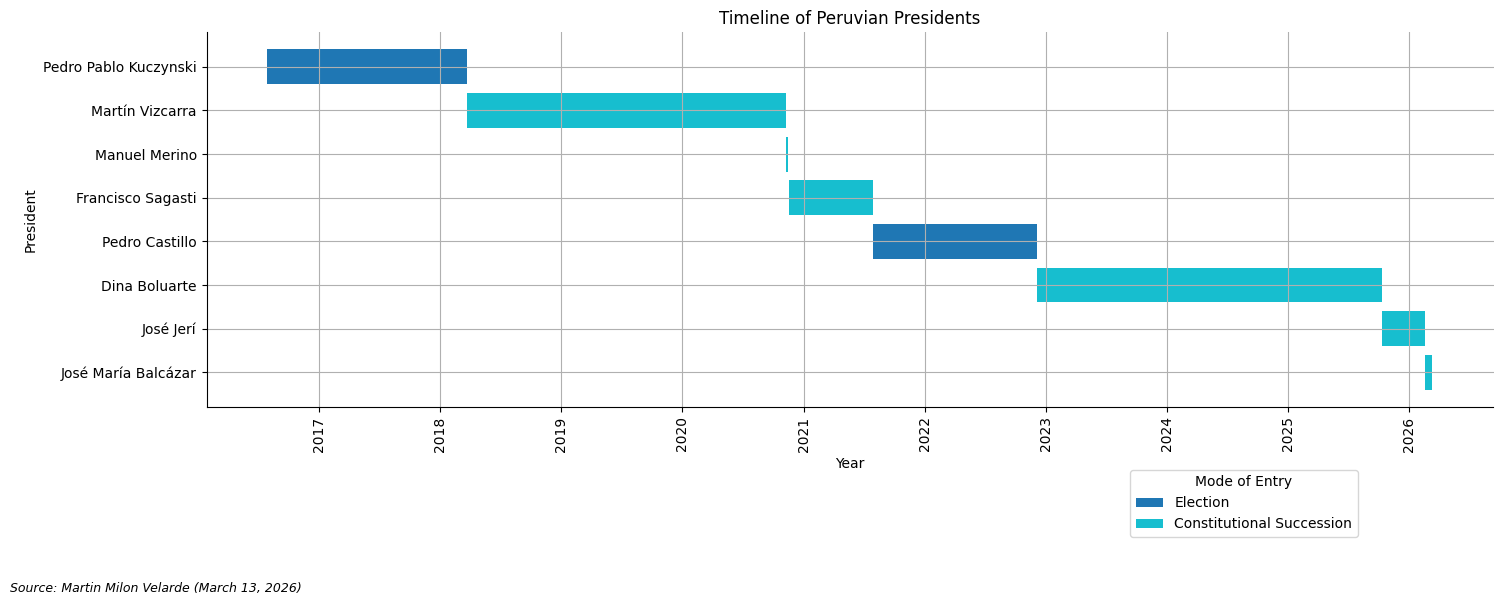

In [70]:
plot_timeline(data2016, "Mode of Entry")

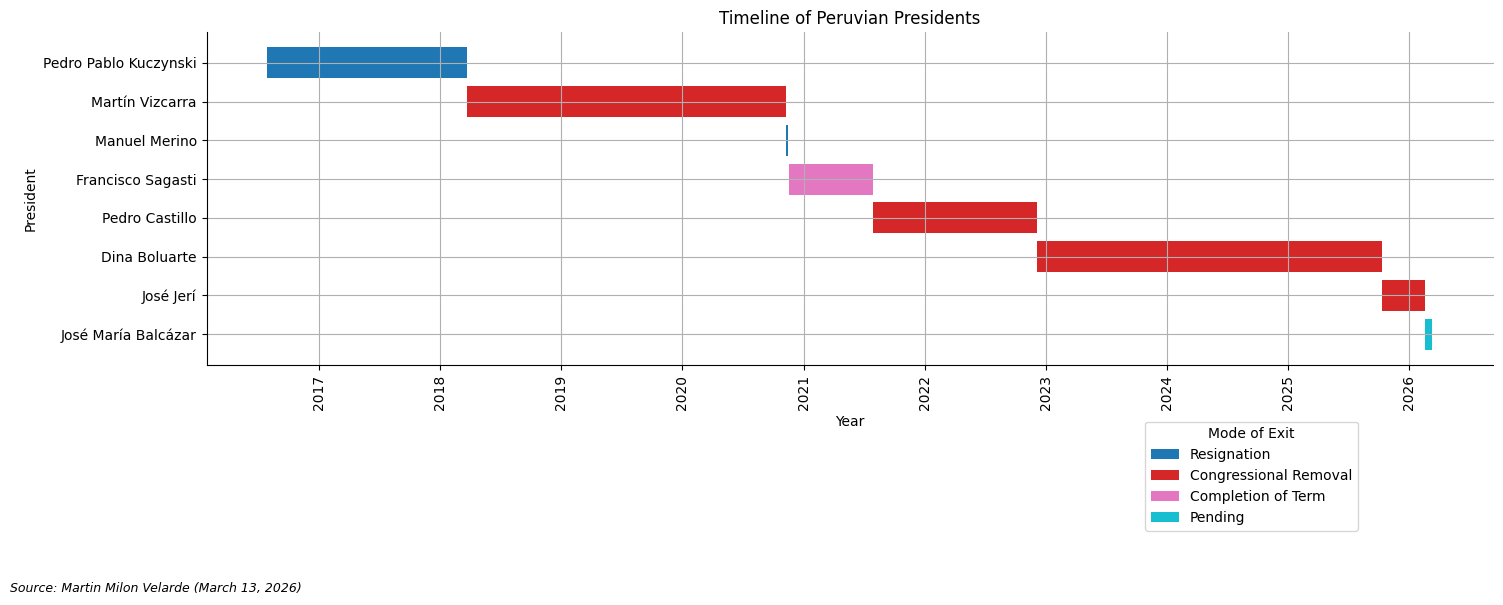

In [71]:
plot_timeline(data2016, "Mode of Exit")

Español:

# Parte 5: Análisis Politico e Institucional

Las visualizaciones generadas en esta sección permiten examinar patrones de estabilidad e inestabilidad presidencial en el Perú desde el retorno a la democracia en 1980. Al combinar información sobre la duración de los mandatos, la forma de acceso al poder y el modo de salida del cargo, los gráficos revelan dinámicas institucionales que ayudan a contextualizar la crisis política contemporánea:

1. En primer lugar, los **gráficos de línea de tiempo** muestran con claridad que el periodo comprendido entre 1980 y 2016 presenta una estructura relativamente estable de alternancia presidencial. Durante estas décadas, la mayoría de los presidentes llegaron al poder mediante elecciones y completaron sus mandatos constitucionales. Incluso durante el régimen de Alberto Fujimori (1990–2000), a pesar de la ruptura institucional provocada por el autogolpe de 1992, el sistema político mantuvo una apariencia de continuidad presidencial.

2. Esta situación cambia radicalmente a partir de 2016. Los gráficos muestran una **aceleración dramática en la rotación presidencial**, donde los mandatos se vuelven cada vez más cortos y las transiciones de poder ocurren con mayor frecuencia. En contraste con el periodo anterior, los presidentes ya no abandonan el poder principalmente por la finalización de su mandato, sino por mecanismos extraordinarios como renuncias forzadas o destituciones congresales.

3. Los **gráficos de duración de mandato** refuerzan este patrón. Mientras que durante gran parte del periodo democrático los presidentes gobernaban aproximadamente cinco años, la duración promedio de los mandatos presidenciales después de 2016 disminuye drásticamente. Algunos gobiernos duran apenas meses o incluso días, lo que evidencia un aumento significativo en la inestabilidad institucional.

4. Asimismo, los gráficos que clasifican los mandatos según **modo de acceso al poder** muestran un cambio importante en la estructura de la sucesión presidencial. Históricamente, el poder ejecutivo fue ocupado principalmente por presidentes elegidos mediante elecciones. Sin embargo, durante la crisis reciente se observa una creciente proporción de presidentes que acceden al poder mediante **sucesión constitucional**, particularmente vicepresidentes o presidentes del Congreso.

5. Finalmente, el análisis del **modo de salida del poder** revela que las destituciones por el Congreso se han convertido en un mecanismo central de cambio presidencial en el Perú contemporáneo. Esto sugiere un sistema político caracterizado por altos niveles de confrontación entre el poder ejecutivo y el legislativo.


---


English:

# Part 5: Political and Institutional Analysis

The visualizations generated in this section make it possible to examine patterns of presidential stability and instability in Peru since the democratic transition of 1980. By combining information on term duration, mode of entry into office, and mode of exit from power, the charts reveal institutional dynamics that help contextualize the contemporary political crisis:

1. First, the **timeline visualizations** clearly show that the period between 1980 and 2016 exhibits a relatively stable structure of presidential alternation. During these decades, most presidents came to power through elections and completed their constitutional terms. Even during the administration of Alberto Fujimori (1990–2000), despite the institutional rupture caused by the 1992 self-coup, the political system maintained a degree of presidential continuity.

2. This pattern changes dramatically after 2016. The charts show a **sharp acceleration in presidential turnover**, where terms become significantly shorter and transitions of power occur much more frequently. In contrast with earlier decades, presidents no longer leave office primarily due to the completion of their terms, but rather through extraordinary mechanisms such as forced resignations or congressional removals.

3. The **term duration charts** reinforce this pattern. While presidents governed for approximately five years during most of the democratic period, the average duration of presidential terms after 2016 declines dramatically. Some administrations last only months or even days, highlighting a significant increase in institutional instability.

4. In addition, the charts that classify presidencies by **mode of entry into office** reveal an important shift in the structure of presidential succession. Historically, the executive branch was primarily occupied by presidents elected through national elections. However, during the recent crisis there is a growing share of presidents who entered office through **constitutional succession**, particularly vice presidents or presidents of Congress.

5. Finally, the analysis of the **mode of exit from office** shows that congressional removal has become a central mechanism of presidential turnover in contemporary Peru. This suggests a political system characterized by intense confrontation between the executive and legislative branches.